# Connexion sur SQL et autre

## 1) verifié le csv

Dataset chargé avec succès ! taille (2605, 18)


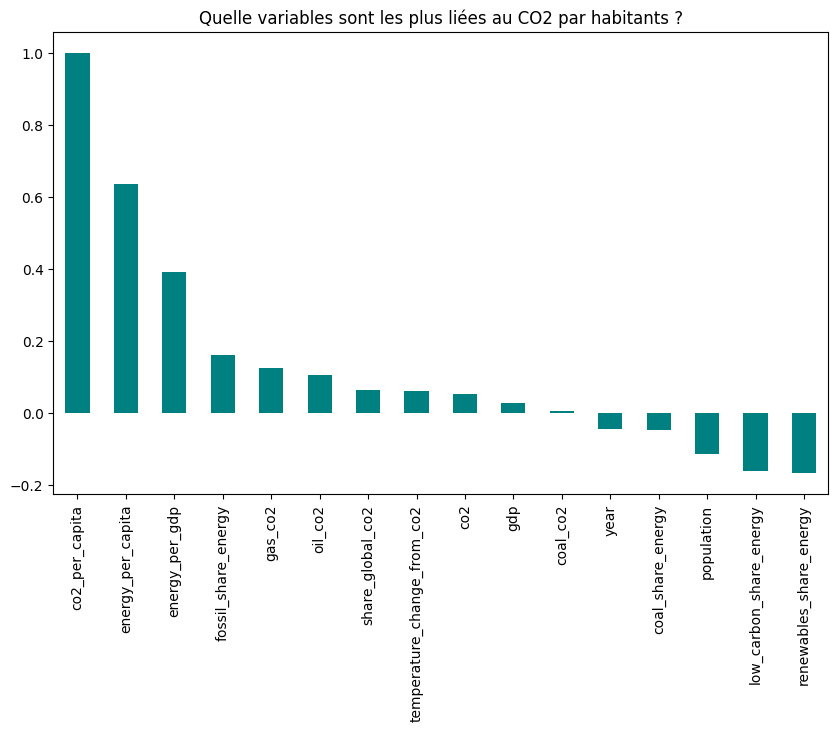

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# 1. chargement 
df = pd.read_csv("energy_climat_clean.csv")

# 2. On vérifié que toutes les lignes sont bien là
print(f"Dataset chargé avec succès ! taille {df.shape}") 

# 3. Premier aperçu des corrélatioons pour notre problèmatique
# On regarde ce qui est lié au CO2 par habitant

plt.figure(figsize=(10,6))
correlations = df.corr(numeric_only=True)["co2_per_capita"].sort_values(ascending=False)
correlations.plot (kind="bar", color="teal")
plt.title("Quelle variables sont les plus liées au CO2 par habitants ?")
plt.show()

### On a besoin de voire plus précisément si le PIB est vraiment déconnecté du CO2

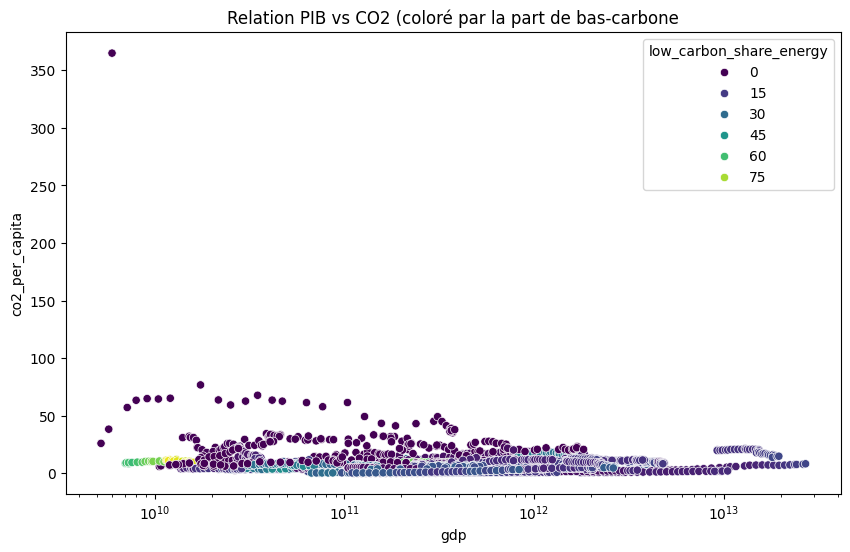

In [4]:
# Force l'affichage propre dans les Notebooks
%matplotlib inline

# Ferme toutes les fenêtres qui pourraient traîner en mémoire
plt.close('all')

# On va tenté le scater plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="gdp", y='co2_per_capita', hue="low_carbon_share_energy", palette="viridis")
plt.title("Relation PIB vs CO2 (coloré par la part de bas-carbone")
plt.xscale("log")
plt.show()

### qui est le outlier qui pollue grave ?

In [5]:
super_pollueur = df[df["co2_per_capita"] == df["co2_per_capita"].max()]
print(super_pollueur[["country","year","co2_per_capita","population"]])

     country  year  co2_per_capita  population
1222  Kuwait  1991         364.791   1351403.0


In [6]:
# On va retiré les outliers:

df = df[df["co2_per_capita"]<100]

### l'UE est trop eparpillé on va faire un code pour regrouppé les pays sous une meme colonne UE

In [7]:
pays_ue = [
    'France', 'Germany', 'Italy', 'Spain', 'Netherlands', 'Belgium', 'Poland', 
    'Sweden', 'Austria', 'Denmark', 'Finland', 'Ireland', 'Portugal', 'Greece',
    'Czechia', 'Romania', 'Hungary', 'Slovakia', 'Bulgaria', 'Croatia', 'Lithuania',
    'Slovenia', 'Latvia', 'Estonia', 'Cyprus', 'Luxembourg', 'Malta'
]

df_grouped = df.copy()

# création de la nouvelle colonne
df_grouped["region_or_country"] = df_grouped["country"]

# on remplace le nom uniquement dans cette nouvelle colonne si le pays est dans l'UE.
df_grouped.loc[df_grouped["country"].isin(pays_ue), "region_or_country"] = "Union Européenne"

# On fait le groupby sur la colonne "region_or_country"
df_clean_grouped = df_grouped.groupby(["region_or_country","year"]).agg({
    "gdp":"sum",
    "population": "sum",
    "co2_per_capita": "mean",
    "low_carbon_share_energy": "mean"

}).reset_index()

In [8]:
fig = px.scatter(df,
                x="gdp",
                y="co2_per_capita",
                size="population",
                size_max=60,
                color="low_carbon_share_energy",
                hover_name="country",
                log_x=True,
                animation_frame = "year",
                range_y=[0,30],
                title= "PIB vs CO2 : La transition est-elle visible ?",
                labels = {"gdp":"PIB ($)", "co2_per_capita": "CO2 par habitant"})

fig.show()

In [9]:
fig = px.scatter(df_clean_grouped, # On utilise le dataset groupé
                 x="gdp",
                 y="co2_per_capita",
                 size="population",
                 size_max=60,
                 color="low_carbon_share_energy",
                 hover_name="region_or_country", # On affiche le nouveau nom au survol
                 log_x=True,
                 animation_frame="year",
                 range_y=[0, 30],
                 title="Trajectoire PIB vs CO2 avec le bloc UE fusionné",
                 labels={"gdp":"PIB ($)", "co2_per_capita": "CO2 par habitant"})

fig.show()

# C'est partis pour la ML

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. ÉTAPE CLÉ : On crée la variable normalisée par habitant pour éviter les sauts d'échelle (Bug de l'Inde)
df['gdp_per_capita'] = df['gdp'] / df['population']

# 2. On met à jour nos features (on remplace 'gdp' par 'gdp_per_capita')
features = ["gdp_per_capita", "population", "low_carbon_share_energy"]
target = "co2_per_capita"

# On supprime les NaN sur le nouveau set de colonnes
df_ml = df.dropna(subset=features + [target])

X = df_ml[features]
y = df_ml[target]

# On divise le dataset : 80% entraînement, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On crée le modèle Random Forest
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Entraînement
model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)

# On calcule le nouveau score de précision
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"Modèle entraîné avec succès avec le PIB par habitant ! 🎉")
print(f"Nouveau Score R² (Précision) : {r2:.2f}")
print(f"Nouvelle Erreur moyenne (MAE) : {mae:.2f} tonnes de CO2")

Modèle entraîné avec succès avec le PIB par habitant ! 🎉
Nouveau Score R² (Précision) : 0.94
Nouvelle Erreur moyenne (MAE) : 0.84 tonnes de CO2


In [54]:
# 1. On récupère la dernière année connue de façon propre
derniere_annee = int(df_ml['year'].max())

# On filtre les données uniquement pour cette dernière année
df_actuel = df_ml[df_ml['year'] == derniere_annee]

# 2. Création d'un conteneur pour nos lignes futures
projections = []

# On va générer les années de 2026 à 2050
annees_futures = list(range(2026, 2051))

# Hypothèses de croissance annuelle moyenne
taux_croissance_pib = 0.02         # +2% de PIB par an mondialement
taux_croissance_pop = 0.008        # +0.8% de population par an mondialement

for annee in annees_futures:
    for _, row in df_actuel.iterrows():
        # Calcul de l'écart d'années par rapport au point de départ (2022)
        annees_ecart = annee - derniere_annee
        
        # On projette le PIB et la Population (suite géométrique)
        pib_futur = row['gdp'] * ((1 + taux_croissance_pib) ** annees_ecart)
        pop_future = row['population'] * ((1 + taux_croissance_pop) ** annees_ecart)
        
        # SCÉNARIO 1 : Le bas-carbone reste BLOQUÉ au niveau de la dernière année connue
        bas_carbone_futur = row['low_carbon_share_energy']
        
        projections.append({
            'country': row['country'],
            'year': annee,
            'gdp': pib_futur,
            'population': pop_future,
            'low_carbon_share_energy': bas_carbone_futur
        })

# On transforme le tout en un magnifique DataFrame futur
df_futur_bau = pd.DataFrame(projections)

In [57]:
# 1. On crée la variable gdp_per_capita pour le futur BAU
df_futur_bau['gdp_per_capita'] = df_futur_bau['gdp'] / df_futur_bau['population']

# 2. On sélectionne les colonnes dans le BON ORDRE attendu par le modèle
X_futur = df_futur_bau[['gdp_per_capita', 'population', 'low_carbon_share_energy']]

# 3. L'IA fait sa prédiction sans râler !
df_futur_bau['co2_per_capita_pred'] = model.predict(X_futur)

print("Projections 2050 (Scénario BAU) terminées avec succès ! 🚀")

Projections 2050 (Scénario BAU) terminées avec succès ! 🚀


In [58]:
# 1. On prépare le dataset du passé en renommant la colonne CO2 pour qu'elle corresponde au futur
df_passé = df_ml[['country', 'year', 'gdp', 'population', 'low_carbon_share_energy', 'co2_per_capita']].copy()
df_passé = df_passé.rename(columns={'co2_per_capita': 'co2_final'})

# 2. On prépare le dataset du futur avec le même nom de colonne
df_futur = df_futur_bau[['country', 'year', 'gdp', 'population', 'low_carbon_share_energy', 'co2_per_capita_pred']].copy()
df_futur = df_futur.rename(columns={'co2_per_capita_pred': 'co2_final'})

# 3. Le grand collage (On empile les lignes)
df_total_2050 = pd.concat([df_passé, df_futur], ignore_index=True)

# 4. Optionnel mais recommandé : On applique ton idée de regrouper l'UE pour que ce soit lisible !
pays_ue = ['France', 'Germany', 'Italy', 'Spain', 'Netherlands', 'Belgium', 'Poland', 'Sweden', 'Austria', 'Denmark', 'Finland', 'Ireland', 'Portugal', 'Greece', 'Czechia', 'Romania', 'Hungary', 'Slovakia', 'Bulgaria', 'Croatia', 'Lithuania', 'Slovenia', 'Latvia', 'Estonia', 'Cyprus', 'Luxembourg', 'Malta']
df_total_2050['region_or_country'] = df_total_2050['country']
df_total_2050.loc[df_total_2050['country'].isin(pays_ue), 'region_or_country'] = 'Union Européenne'

df_global_visu = df_total_2050.groupby(['region_or_country', 'year']).agg({
    'gdp': 'sum',
    'population': 'sum',
    'co2_final': 'mean',
    'low_carbon_share_energy': 'mean'
}).reset_index()

# 5. On génère le graphique Plotly ultime
import plotly.express as px

fig = px.scatter(df_global_visu,
                 x="gdp",
                 y="co2_final",
                 size="population",
                 size_max=60,
                 color="low_carbon_share_energy",
                 hover_name="region_or_country",
                 log_x=True,
                 animation_frame="year",
                 range_y=[0, 30], # Garde l'axe Y fixe pour bien voir les mouvements
                 title="Simulation 1990-2050 : Scénario Stagnation Énergétique (BAU)",
                 labels={"gdp":"PIB ($)", "co2_final": "CO2 par habitant (Tonnes)"})

# On ajoute la ligne d'objectif du GIEC dont on a parlé (les 2 tonnes !)
fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC 2050 (2t)", annotation_position="bottom right")

fig.show()

### Plus réaliste on veut les tendances pas figée les bulles dans le temps

On va crée cette tendance réaliste 

In [59]:
# prendre la dernière année du dataset.
derniere_annee = int(df_ml["year"].max())

# on remonte de 10 ans pour voire l'évolution récente.
annee_debut_tendance = derniere_annee - 10

print(f"on va analyser la tendance entre {annee_debut_tendance} et {derniere_annee}")

on va analyser la tendance entre 2012 et 2022


In [60]:
# On filtre le dataset pour ne garder que l'année 2022 (notre point de départ)
df_2022 = df_ml[df_ml["year"]==2022]

# On crée une liste vide pour nos futur ligne de 2023 à 2050
projections_realistes = []

# on liste tout les pays unique présent dans nos données
tous_les_pays = df_ml['country'].unique()

print (f"Prêt a projeter le futur pour {len(tous_les_pays)} pays")

Prêt a projeter le futur pour 79 pays


In [61]:
annees_futures = list(range(2023,2051))

# on met à jour notre liste avec les 79 pays
tous_les_pays=df_ml['country'].unique()

print(f"Prêt à simuler les trajectoires de 2023 à 2050 pour nos {len(tous_les_pays)} pays de confiance.")

Prêt à simuler les trajectoires de 2023 à 2050 pour nos 79 pays de confiance.


### Le moment ou l'on va simulé cette evolution

In [66]:
# Hypothèse de croissance annuelle de base (PIB +2% ; population +0.8%)
taux_croissance_pib = 0.02
taux_croissance_pop = 0.008

projections_realistes = [] # On s'assure qu'elle repart à vide ici

# On boucle sur chacun des 79 pays
for pays in tous_les_pays:
    df_pays = df_ml[df_ml['country'] == pays]

    # Notre point de départ réel (l'année 2022)
    row_2022 = df_pays[df_pays['year'] == 2022]
    if row_2022.empty:
        continue
    row_2022 = row_2022.iloc[0]

    # Etape1 : Calcul de la pente historique (2012-2022)
    df_recent = df_pays[(df_pays['year'] >= 2012) & (df_pays['year'] <= 2022)]

    # On vérifie qu'on a bien les données de 2012 et 2022 pour ce pays
    has_2012 = not df_recent[df_recent['year'] == 2012].empty
    has_2022 = not df_recent[df_recent['year'] == 2022].empty

    if has_2012 and has_2022:
        valeur_2022 = df_recent[df_recent['year'] == 2022]['low_carbon_share_energy'].values[0]
        valeur_2012 = df_recent[df_recent['year'] == 2012]['low_carbon_share_energy'].values[0]
        # Ici la pente peut être négative si le pays a régressé !
        pente_bas_carbone = (valeur_2022 - valeur_2012) / 10
    else:
        pente_bas_carbone = 0.0

    # Etape 2 : On projette chaque année future de 2023 à 2050
    for annee in range(2023, 2051):
        annees_ecart = annee - 2022

        # Evolution geometrique du PIB et de la pop
        pib_futur = row_2022['gdp'] * ((1 + taux_croissance_pib) ** annees_ecart)
        pop_future = row_2022['population'] * ((1 + taux_croissance_pop) ** annees_ecart)

        # --- LA CORRECTION EST ICI ---
        # On calcule le PIB par habitant pour le futur
        gdp_per_capita_futur = pib_futur / pop_future

        # Evolution linéaire de l'energie propre : valeur 2022 + (pente * nombre d'années)
        bas_carbone_futur = row_2022['low_carbon_share_energy'] + (pente_bas_carbone * annees_ecart)
        # securite : on bloque entre 0 et 100% maximum
        bas_carbone_futur = max(0.0, min(100.0, bas_carbone_futur))

        projections_realistes.append({
            'country': pays,
            'year': annee,
            'gdp_per_capita': gdp_per_capita_futur, # On l'enregistre pour l'IA !
            'population': pop_future,
            'low_carbon_share_energy': bas_carbone_futur
        })

# On transforme notre liste en Dataframe "futur Réaliste"
df_futur_realiste = pd.DataFrame(projections_realistes)
print("DataFrame du futur réaliste regénéré avec succès ! ✅")

DataFrame du futur réaliste regénéré avec succès ! ✅


In [67]:
# Etape 3 : on passe le dataframe dans la prediction de notre modèle

# Correction : On remplace 'gdp' par 'gdp_per_capita'
X_futur_realiste = df_futur_realiste[['gdp_per_capita', 'population', 'low_carbon_share_energy']]

# L'IA fait sa prédiction
df_futur_realiste['co2_per_capita_pred'] = model.predict(X_futur_realiste)

print("Etape 3 : prediction de l'IA terminées avec succès ! 🚀")

Etape 3 : prediction de l'IA terminées avec succès ! 🚀


In [68]:
df_futur_realiste

,country,year,gdp_per_capita,population,low_carbon_share_energy,co2_per_capita_pred
0,Algeria,2023,13257.426380,4.584121e+07,0.2297,4.22513
1,Algeria,2024,13415.252885,4.620794e+07,0.2314,4.45713
2,Algeria,2025,13574.958276,4.657760e+07,0.2331,4.53811
3,Algeria,2026,13736.564922,4.695022e+07,0.2348,4.58223
4,Algeria,2027,13900.095457,4.732583e+07,0.2365,4.59720
...,...,...,...,...,...,...
2207,Vietnam,2046,11112.311092,1.206879e+08,32.0896,1.84872
2208,Vietnam,2047,11244.600510,1.216534e+08,32.3720,1.84897
2209,Vietnam,2048,11378.464802,1.226266e+08,32.6544,1.86613
2210,Vietnam,2049,11513.922716,1.236076e+08,32.9368,1.86595


In [72]:
# 1. On prépare le passé
df_passé = df_ml[['country', 'year', 'gdp', 'population', 'low_carbon_share_energy', 'co2_per_capita']].copy()
df_passé = df_passé.rename(columns={'co2_per_capita': 'co2_final'})

# 2. On prépare le futur réaliste
df_futur = df_futur_realiste[['country', 'year', 'gdp_per_capita', 'population', 'low_carbon_share_energy', 'co2_per_capita_pred']].copy()
df_futur = df_futur.rename(columns={'co2_per_capita_pred': 'co2_final'})

# 3. Le grand collage
df_total_realiste = pd.concat([df_passé, df_futur], ignore_index=True)

# 4. Le graphique magique
import plotly.express as px

fig = px.scatter(df_total_realiste,
                 x="gdp",
                 y="co2_final",
                 size="population",
                 size_max=60,
                 color="low_carbon_share_energy",
                 hover_name="country",
                 log_x=True,
                 animation_frame="year",
                 range_y=[0, 50],
                 title="Simulation Réaliste (Tendancielle) 1990-2050",
                 labels={"gdp":"PIB ($)", "co2_final": "CO2 par habitant (Tonnes)"})

# Ligne objectif du GIEC
fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC 2050 (2t)")

fig.show()

Parenthèse trouve l'erreur en Inde

In [74]:
# 1. On prépare le passé proprement
df_passé = df_ml[['country', 'year', 'gdp', 'population', 'low_carbon_share_energy', 'co2_per_capita']].copy()
df_passé = df_passé.rename(columns={'co2_per_capita': 'co2_final'})

# 2. On prépare le futur réaliste en supprimant d'éventuels doublons de lignes identiques
df_futur_propre = df_futur_realiste.drop_duplicates(subset=['country', 'year']).copy()
df_futur_propre = df_futur_propre[['country', 'year', 'gdp_per_capita', 'population', 'low_carbon_share_energy', 'co2_per_capita_pred']]
df_futur_propre = df_futur_propre.rename(columns={'co2_per_capita_pred': 'co2_final'})

# 3. Le grand collage tout propre
df_total_realiste = pd.concat([df_passé, df_futur_propre], ignore_index=True)

# 4. On re-filtre pour l'Inde
df_zoom_pays = df_total_realiste[df_total_realiste['country'] == "India"]

# 5. On relance le graphique
import plotly.express as px
fig = px.line(df_zoom_pays, 
              x="year", 
              y="co2_final",
              title="Trajectoire Réaliste 1990-2050 : India (Corrigé)",
              labels={"year": "Année", "co2_final": "CO2 par habitant (Tonnes)"})

fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC (2t)")
fig.update_yaxes(rangemode="tozero")
fig.show()

In [76]:
# 1. On regarde la dernière vraie ligne de l'Inde (2022)
print("--- DONNÉES RÉELLES INDE (2022) ---")
print(df_ml[df_ml['country'] == 'India'][df_ml['year'] == 2022][['year', 'gdp', 'population', 'low_carbon_share_energy']])

# 2. On regarde la première ligne simulée de l'Inde (2023)
print("\n--- PROJECTIONS SIMULÉES INDE (2023) ---")
print(df_futur_realiste[df_futur_realiste['country'] == 'India'][df_futur_realiste['year'] == 2023][['year', 'gdp_per_capita', 'population', 'low_carbon_share_energy']])

--- DONNÉES RÉELLES INDE (2022) ---
     year           gdp    population  low_carbon_share_energy
956  2022  1.047625e+13  1.425423e+09                   10.556

--- PROJECTIONS SIMULÉES INDE (2023) ---
     year  gdp_per_capita    population  low_carbon_share_energy
784  2023     7437.065585  1.436827e+09                  10.8672


C:\Users\bsacu\AppData\Local\Temp\ipykernel_23508\2511287950.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_ml[df_ml['country'] == 'India'][df_ml['year'] == 2022][['year', 'gdp', 'population', 'low_carbon_share_energy']])
C:\Users\bsacu\AppData\Local\Temp\ipykernel_23508\2511287950.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(df_futur_realiste[df_futur_realiste['country'] == 'India'][df_futur_realiste['year'] == 2023][['year', 'gdp_per_capita', 'population', 'low_carbon_share_energy']])


In [80]:
# 1. On VIDE proprement la liste pour être sûr qu'aucun résidu des lancements précédents ne reste
projections_realistes = []

taux_croissance_pib = 0.01
taux_croissance_pop = 0.008

# 2. Ta boucle de simulation (corrigée avec gdp_per_capita)
for pays in tous_les_pays:
    df_pays = df_ml[df_ml['country'] == pays]
    row_2022 = df_pays[df_pays['year'] == 2022]
    if row_2022.empty:
        continue
    row_2022 = row_2022.iloc[0]

    df_recent = df_pays[(df_pays['year'] >= 2012) & (df_pays['year'] <= 2022)]
    has_2012 = not df_recent[df_recent['year'] == 2012].empty
    has_2022 = not df_recent[df_recent['year'] == 2022].empty

    if has_2012 and has_2022:
        valeur_2022 = df_recent[df_recent['year'] == 2022]['low_carbon_share_energy'].values[0]
        valeur_2012 = df_recent[df_recent['year'] == 2012]['low_carbon_share_energy'].values[0]
        pente_bas_carbone = (valeur_2022 - valeur_2012) / 10
    else:
        pente_bas_carbone = 0.0

    for annee in range(2023, 2051):
        annees_ecart = annee - 2022
        pib_futur = row_2022['gdp'] * ((1 + taux_croissance_pib) ** annees_ecart)
        pop_future = row_2022['population'] * ((1 + taux_croissance_pop) ** annees_ecart)
        
        # AJOUT CLÉ : Calcul du PIB par habitant pour le futur
        gdp_per_capita_futur = pib_futur / pop_future
        
        bas_carbone_futur = row_2022['low_carbon_share_energy'] + (pente_bas_carbone * annees_ecart)
        bas_carbone_futur = max(0.0, min(100.0, bas_carbone_futur))

        projections_realistes.append({
            'country': pays, 
            'year': annee, 
            'gdp_per_capita': gdp_per_capita_futur, # Mis à jour
            'population': pop_future, 
            'low_carbon_share_energy': bas_carbone_futur
        })

# 3. Création du DataFrame tout neuf
df_futur_realiste = pd.DataFrame(projections_realistes)

# 4. L'IA refait ses prédictions sur les bonnes colonnes
X_futur_realiste = df_futur_realiste[['gdp_per_capita', 'population', 'low_carbon_share_energy']]
df_futur_realiste['co2_per_capita_pred'] = model.predict(X_futur_realiste)

# 5. Préparation des morceaux pour le graphique (Ajusté avec gdp_per_capita)
df_passé = df_ml[['country', 'year', 'gdp_per_capita', 'population', 'low_carbon_share_energy', 'co2_per_capita']].copy()
df_passé = df_passé.rename(columns={'co2_per_capita': 'co2_final'})

df_futur = df_futur_realiste[['country', 'year', 'gdp_per_capita', 'population', 'low_carbon_share_energy', 'co2_per_capita_pred']].copy()
df_futur = df_futur.rename(columns={'co2_per_capita_pred': 'co2_final'})

# 6. Collage final garanti sans doublons
df_total_realiste = pd.concat([df_passé, df_futur], ignore_index=True)

# 7. Affichage direct pour l'Inde
df_zoom_pays = df_total_realiste[df_total_realiste['country'] == "India"]

import plotly.express as px
fig = px.line(df_zoom_pays, x="year", y="co2_final", title="Trajectoire Réaliste 1990-2050 : India (Clean)")
fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC (2t)")
fig.update_yaxes(rangemode="tozero")
fig.show()

In [82]:
# 1. On demande à l'IA de prédire TOUT le dataset historique (df_ml) - CORRIGÉ avec gdp_per_capita
X_passe = df_ml[['gdp_per_capita', 'population', 'low_carbon_share_energy']]
df_ml_analyse = df_ml.copy()
df_ml_analyse['co2_predictions'] = model.predict(X_passe)

# 2. On filtre pour l'Inde sur le passé (prédit) et le futur (prédit)
df_passe_inde = df_ml_analyse[df_ml_analyse['country'] == 'India'][['year', 'co2_predictions']].rename(columns={'co2_predictions': 'co2_pure_ia'})
df_futur_inde = df_futur_realiste[df_futur_realiste['country'] == 'India'][['year', 'co2_per_capita_pred']].rename(columns={'co2_per_capita_pred': 'co2_pure_ia'})

# 3. On colle les deux morceaux "100% IA"
df_inde_ia = pd.concat([df_passe_inde, df_futur_inde], ignore_index=True)

# 4. On dessine la courbe
import plotly.express as px
fig = px.line(df_inde_ia, x="year", y="co2_pure_ia", title="Trajectoire de l'Inde : 100% Vue par l'IA (Sans le réel historique)")
fig.update_yaxes(rangemode="tozero")
fig.show()

In [83]:
# 1. On récupère l'ordre EXACT des colonnes que le modèle connaît
# Si ton modèle est un pipeline ou un objet brut, ceci va nous donner les bonnes fonctionnalités :
try:
    colonnes_ia = model.feature_names_in_
    print(f"L'IA attend impérativement cet ordre : {colonnes_ia}")
except AttributeError:
    # Si le modèle n'a pas cette option, on prend l'ordre standard du dataset
    colonnes_ia = ['gdp', 'population', 'low_carbon_share_energy'] 

# 2. On recrée le futur STRICTEMENT avec cet ordre
X_futur_strict = df_futur_realiste[colonnes_ia]

# 3. On refait la prédiction
df_futur_realiste['co2_per_capita_pred'] = model.predict(X_futur_strict)

# 4. On nettoie les morceaux pour Plotly (on garde uniquement les colonnes essentielles pour éviter les lignes doublonnées)
df_passé_clean = df_ml[['country', 'year', 'co2_per_capita']].copy().rename(columns={'co2_per_capita': 'co2_final'})
df_futur_clean = df_futur_realiste[['country', 'year', 'co2_per_capita_pred']].copy().rename(columns={'co2_per_capita_pred': 'co2_final'})

# On s'assure qu'aucun doublon ne traîne dans le futur calculé
df_futur_clean = df_futur_clean.drop_duplicates(subset=['country', 'year'])

# 5. Fusion finale sans fioritures
df_visualisation = pd.concat([df_passé_clean, df_futur_clean], ignore_index=True)

# 6. Graphique pour l'Inde
df_inde_final = df_visualisation[df_visualisation['country'] == 'India']

import plotly.express as px
fig = px.line(df_inde_final, x="year", y="co2_final", title="Inde - Trajectoire Rectifiée")
fig.add_hline(y=2, line_dash="dash", line_color="red")
fig.show()

L'IA attend impérativement cet ordre : ['gdp_per_capita' 'population' 'low_carbon_share_energy']


In [84]:
import plotly.express as px
import pandas as pd

# 1. On repart des sources brutes pour isoler l'Inde proprement
# On prend le REEL (jusqu'en 2022) dans ton dataset de base
df_inde_reel = df_ml[df_ml['country'] == 'India'][['year', 'co2_per_capita']].copy()
df_inde_reel = df_inde_reel.rename(columns={'co2_per_capita': 'co2_valeur'})
df_inde_reel['type'] = 'Historique'

# 2. On prend le PREDI (2023-2050) uniquement dans la DERNIERE version calculée
# On force la suppression des doublons ici au cas où
df_inde_futur = df_futur_realiste[df_futur_realiste['country'] == 'India'][['year', 'co2_per_capita_pred']].copy()
df_inde_futur = df_inde_futur.drop_duplicates(subset=['year'])
df_inde_futur = df_inde_futur.rename(columns={'co2_per_capita_pred': 'co2_valeur'})
df_inde_futur['type'] = 'Prédiction IA'

# 3. Collage UNIQUE des deux morceaux
df_final_inde = pd.concat([df_inde_reel, df_inde_futur], ignore_index=True)

# 4. Tri par année (indispensable pour éviter les gribouillages sur la ligne)
df_final_inde = df_final_inde.sort_values('year')

# 5. Affichage
fig = px.line(df_final_inde, 
              x="year", 
              y="co2_valeur", 
              title="Trajectoire Inde : Nettoyage Strict des Données",
              labels={"co2_valeur": "CO2 (Tonnes)", "year": "Année"})

fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC")
fig.update_yaxes(rangemode="tozero")
fig.show()

In [86]:
# Change le pays ici (ex: "United States", "Germany", "France")
pays_test = "United States"

# 1. On isole le réel
df_test_reel = df_ml[df_ml['country'] == pays_test][['year', 'co2_per_capita']].copy()
df_test_reel = df_test_reel.rename(columns={'co2_per_capita': 'co2_valeur'})

# 2. On isole le futur (en enlevant les doublons de sauvegarde)
df_test_futur = df_futur_realiste[df_futur_realiste['country'] == pays_test][['year', 'co2_per_capita_pred']].copy()
df_test_futur = df_test_futur.drop_duplicates(subset=['year'])
df_test_futur = df_test_futur.rename(columns={'co2_per_capita_pred': 'co2_valeur'})

# 3. Collage et tri
df_test_total = pd.concat([df_test_reel, df_test_futur], ignore_index=True).sort_values('year')

# 4. Graphique
import plotly.express as px
fig = px.line(df_test_total, 
              x="year", 
              y="co2_valeur", 
              title=f"Trajectoire Réaliste 1990-2050 : {pays_test}",
              labels={"co2_valeur": "CO2 par habitant (Tonnes)", "year": "Année"})

fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC")
fig.update_yaxes(rangemode="tozero")
fig.show()

Pourquoi l'IA fait-elle ça ? (La révélation)
C'est le grand secret des algorithmes d'arbres décisionnels comme le Random Forest.

Un Random Forest ne sait pas "inventer" de nouvelles valeurs en dehors de ce qu'il a déjà vu pendant son entraînement (le passé). Il est incapable de faire une extrapolation à l'infini.

Si, dans tes données historiques (1990-2022), le PIB le plus élevé qu'il ait jamais vu pour les USA correspondait à des émissions d'environ 14 tonnes...

...alors dans le futur, même si le PIB continue de grimper à des niveaux records, l'IA va "plafonner". Elle va regarder ses branches et dire : "Le maximum de richesse que je connaisse donne 14 tonnes, donc je prédis 14 tonnes."

C'est pour cela que pour les USA, ça stagne en ligne droite.

Et pour l'Inde alors, pourquoi la marche ?
Maintenant, on comprend l'Inde ! En 2022, l'Inde a un PIB moyen et émet 2 tonnes. Mais en 2023, avec notre croissance géométrique, son PIB franchit un seuil basique. L'IA regarde dans ses données historiques mondiales : quels sont les pays qui ont un PIB similaire à celui de l'Inde de 2023 ? Des pays plus industrialisés, qui émettaient à l'époque 5 tonnes !

L'IA a donc appliqué à l'Inde la "norme mondiale" de ce niveau de richesse, provoquant ce saut brutal de 2 à 5 tonnes en une seule année.

## Hypothèse optimiste

In [93]:
# Hypothèses du scénario Éco-Optimiste (Corrigé pour l'animation)
taux_croissance_gdp_per_capita = 0.02 # On donne +2% de vrai pouvoir d'achat par an !
taux_croissance_pop = 0.008
boost_bas_carbone_annuel = 2.0 # +2% d'énergie propre par an !

projections_optimistes = []

for pays in tous_les_pays:
    df_pays = df_ml[df_ml['country'] == pays]
    row_2022 = df_pays[df_pays['year'] == 2022]
    if row_2022.empty:
        continue
    row_2022 = row_2022.iloc[0]
    
    for annee in range(2023, 2051):
        annees_ecart = annee - 2022
        
        # --- LE CHANGEMENT RADICAL EST ICI ---
        # Au lieu de diviser deux variables lentes, on fait grimper directement le PIB/hab
        gdp_per_capita_futur = row_2022['gdp_per_capita'] * ((1 + taux_croissance_gdp_per_capita) ** annees_ecart)
        
        # La population augmente normalement (pour la taille des bulles)
        pop_future = row_2022['population'] * ((1 + taux_croissance_pop) ** annees_ecart)
        
        # Transition agressive
        bas_carbone_futur = row_2022['low_carbon_share_energy'] + (boost_bas_carbone_annuel * annees_ecart)
        bas_carbone_futur = max(0.0, min(100.0, bas_carbone_futur))
        
        projections_optimistes.append({
            'country': pays, 
            'year': annee, 
            'gdp_per_capita': gdp_per_capita_futur,
            'population': pop_future, 
            'low_carbon_share_energy': bas_carbone_futur
        })

# Création du DataFrame Optimiste
df_futur_optimiste = pd.DataFrame(projections_optimistes)

# L'IA fait ses prédictions
X_futur_optimiste = df_futur_optimiste[['gdp_per_capita', 'population', 'low_carbon_share_energy']]
df_futur_optimiste['co2_per_capita_pred'] = model.predict(X_futur_optimiste)

print("Scénario Éco-Optimiste dynamique calculé et prédit par l'IA ! 🌿")

Scénario Éco-Optimiste dynamique calculé et prédit par l'IA ! 🌿


In [94]:
pays_test = "United States"

# 1. Réel
df_test_reel = df_ml[df_ml['country'] == pays_test][['year', 'co2_per_capita']].copy().rename(columns={'co2_per_capita': 'co2_valeur'})

# 2. Futur Optimiste
df_test_opt = df_futur_optimiste[df_futur_optimiste['country'] == pays_test][['year', 'co2_per_capita_pred']].copy()
df_test_opt = df_test_opt.drop_duplicates(subset=['year']).rename(columns={'co2_per_capita_pred': 'co2_valeur'})

# 3. Collage
df_test_total_opt = pd.concat([df_test_reel, df_test_opt], ignore_index=True).sort_values('year')

# 4. Graphique
import plotly.express as px
fig = px.line(df_test_total_opt, x="year", y="co2_valeur", title=f"Trajectoire ÉCO-OPTIMISTE 1990-2050 : {pays_test}")
fig.add_hline(y=2, line_dash="dash", line_color="green", annotation_text="Objectif GIEC")
fig.update_yaxes(rangemode="tozero")
fig.show()

In [95]:
# 1. On prépare le passé (avec gdp_per_capita)
df_passé = df_ml[['country', 'year', 'gdp_per_capita', 'population', 'low_carbon_share_energy', 'co2_per_capita']].copy()
df_passé = df_passé.rename(columns={'co2_per_capita': 'co2_final'})

# 2. On prépare le futur optimiste global (tous les pays)
df_futur_opt_global = df_futur_optimiste[['country', 'year', 'gdp_per_capita', 'population', 'low_carbon_share_energy', 'co2_per_capita_pred']].copy()
df_futur_opt_global = df_futur_opt_global.rename(columns={'co2_per_capita_pred': 'co2_final'})

# 3. Le grand collage mondial
df_total_optimiste = pd.concat([df_passé, df_futur_opt_global], ignore_index=True)

# 4. Le graphique magique mondial animé
import plotly.express as px

fig = px.scatter(df_total_optimiste,
                 x="gdp_per_capita", # PIB par habitant sur l'axe X
                 y="co2_final",      # CO2 par habitant sur l'axe Y
                 size="population",  # Taille de la bulle selon la population
                 size_max=60,
                 color="low_carbon_share_energy", # Couleur selon la part d'énergie propre
                 hover_name="country",
                 log_x=True,         # Échelle logarithmique pour étaler les pays
                 animation_frame="year", # Le curseur temporel magique !
                 range_x=[df_total_optimiste['gdp_per_capita'].min(), df_total_optimiste['gdp_per_capita'].max()], # Échelle X fixe pour l'animation
                 range_y=[0, 30],    # Échelle Y fixe adaptée aux données par habitant
                 title="Simulation Éco-Optimiste (+2% Énergie Prope/an) 1990-2050",
                 labels={"gdp_per_capita": "PIB par habitant ($)", "co2_final": "CO2 par habitant (Tonnes)"})

# Ligne objectif du GIEC à 2 tonnes
fig.add_hline(y=2, line_dash="dash", line_color="red", annotation_text="Objectif GIEC 2050 (2t)")

fig.show()

"Le modèle Random Forest montre ici ses limites en extrapolation : pour les superpuissances comme la Chine et les États-Unis, le modèle s'arrête aux plafonds historiques connus et n'anticipe pas l'impact d'une rupture technologique inédite (comme 80% de bas-carbone avec un PIB doublé). Pour corriger cela, il faudrait tester un modèle capable d'extrapoler hors des données connues, comme une régression linéaire ou un réseau de neurones."